<a href="https://colab.research.google.com/github/zeynkash/Speech_Command_Classification/blob/main/speech_command_classification_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Drive Mount

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import subprocess
import shutil
from google.colab import userdata

In [ ]:
DRIVE_SAVE_DIR = "/content/drive/MyDrive/Speech_Command_Classification/Results"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

In [ ]:
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_creds = {"username": userdata.get('KAGGLE_USERNAME'), "key": userdata.get('KAGGLE_KEY')}


config_path = os.path.join(kaggle_dir, "kaggle.json")
with open(config_path, "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(config_path, 0o600)

print("Downloading dataset...")
subprocess.run(["pip", "install", "kaggle", "-q"])
subprocess.run(["kaggle", "datasets", "download", "-d", "yashdogra/speech-commands"], check=True)

extract_path = "/content/speech_commands"
zip_file = "speech-commands.zip"

if os.path.exists(zip_file):
    print(f"Extracting to {extract_path}...")
    shutil.unpack_archive(zip_file, extract_path)
    os.remove(zip_file)
else:
    print("Zip file not found. Check if the download was successful.")

if os.path.exists(extract_path):
    print("\nExtraction Complete. Files in directory:")
    print(os.listdir(extract_path))

Extracting to /content/speech_commands...

Extraction Complete. Files in directory:
['yes', 'marvin', 'right', 'dog', 'backward', 'on', 'down', 'nine', 'up', 'left', 'seven', 'visual', 'off', 'cat', 'four', 'one', 'wow', 'happy', 'eight', 'validation_list.txt', 'six', 'bird', 'go', 'no', 'learn', 'five', 'two', 'stop', 'bed', 'house', 'sheila', '_background_noise_', 'three', 'README.md', 'forward', 'zero', 'LICENSE', 'testing_list.txt', 'tree', 'follow']


In [ ]:
sorted(os.listdir(extract_path))

['LICENSE',
 'README.md',
 '_background_noise_',
 'backward',
 'bed',
 'bird',
 'cat',
 'dog',
 'down',
 'eight',
 'five',
 'follow',
 'forward',
 'four',
 'go',
 'happy',
 'house',
 'learn',
 'left',
 'marvin',
 'nine',
 'no',
 'off',
 'on',
 'one',
 'right',
 'seven',
 'sheila',
 'six',
 'stop',
 'testing_list.txt',
 'three',
 'tree',
 'two',
 'up',
 'validation_list.txt',
 'visual',
 'wow',
 'yes',
 'zero']

# See What i have

In [ ]:
import os
import pandas as pd

DATA_DIR = "/content/speech_commands"


rows = []


for folder in sorted(os.listdir(DATA_DIR)):
  folder_path = os.path.join(DATA_DIR, folder)
  if os.path.isdir(folder_path):
    # extract .wav files from each subfolder
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    rows.append({"class": folder, "num_samples": len(files)})



df = pd.DataFrame(rows)
df["percentage"] = (df["num_samples"] / df["num_samples"].sum() * 100).round(2)
print(f"Total samples: {df['num_samples'].sum()}")
df

Total samples: 105835


,class,num_samples,percentage
0,_background_noise_,6,0.01
1,backward,1664,1.57
2,bed,2014,1.90
3,bird,2064,1.95
4,cat,2031,1.92
5,dog,2128,2.01
6,down,3917,3.70
7,eight,3787,3.58
8,five,4052,3.83
9,follow,1579,1.49


# Install Libraries

In [ ]:
import os
import numpy as np
import librosa # process, analyse wav files
from tqdm import tqdm

# Extract spectrograms

In [ ]:
import os
import numpy as np
import librosa

DATA_DIR = "/content/speech_commands"
CLASSES = ['go', 'stop', 'up', 'down', 'left', 'right', 'yes', 'no']
SAVE_DIR = "/content/processed"
os.makedirs(SAVE_DIR, exist_ok=True)

SR = 16000
DURATION = 1.0
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 160

def load_audio(path):
    y, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
    target_len = int(SR * DURATION)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def extract_melspectrogram(y):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
        )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db  # Shape: (64, 101)

X, y_labels = [], []


for label, cls in enumerate(CLASSES):
    cls_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.endswith('.wav')]
    print(f"Processing {cls}...")
    for fname in tqdm(files):
        try:
            audio = load_audio(os.path.join(cls_path, fname))
            mel = extract_melspectrogram(audio)
            X.append(mel)
            y_labels.append(label)
        except Exception as e:
            pass

X = np.array(X, dtype=np.float32)
y_labels = np.array(y_labels, dtype=np.int64)

np.save(os.path.join(SAVE_DIR, "X_mel.npy"), X)
np.save(os.path.join(SAVE_DIR, "y_labels.npy"), y_labels)

print(f"\n✅ Done!")
print(f"X shape: {X.shape}")
print(f"y shape: {y_labels.shape}")

Processing go...


100%|██████████| 3880/3880 [00:33<00:00, 114.39it/s]


Processing stop...


100%|██████████| 3872/3872 [00:14<00:00, 260.26it/s]


Processing up...


...

Processing yes...


100%|██████████| 4044/4044 [00:16<00:00, 248.56it/s]


Processing no...


100%|██████████| 3941/3941 [00:15<00:00, 254.92it/s]



✅ Done!
X shape: (30956, 64, 101)
y shape: (30956,)


## Save to Drive

In [ ]:
np.save(os.path.join(DRIVE_SAVE_DIR, "X_mel.npy"), X)
np.save(os.path.join(DRIVE_SAVE_DIR, "y_labels.npy"), y_labels)

print("✅ Saved to Google Drive!")
print("Path:", DRIVE_SAVE_DIR)

✅ Saved to Google Drive!
Path: /content/drive/MyDrive/Speech_Command_Classification/Results


## Visualize Mel-Spectrogram

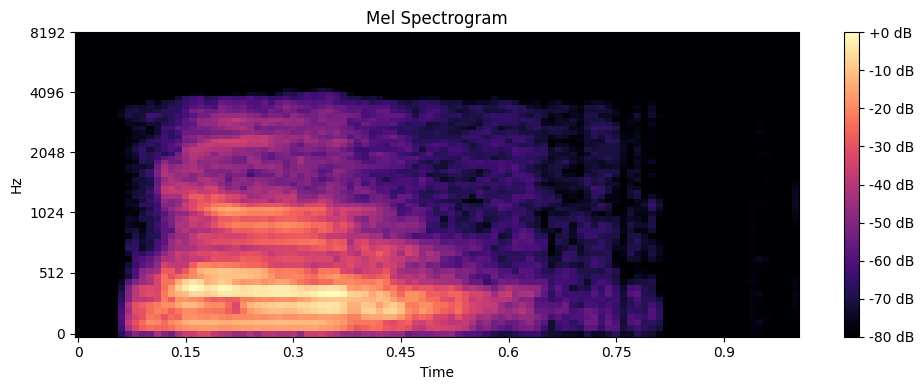

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# take one example
sample_mel = X[0]

plt.figure(figsize=(10, 4))
librosa.display.specshow(sample_mel, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()

# Prepare Dataset

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

# Load processed data
X = np.load("/content/processed/X_mel.npy")
y = np.load("/content/processed/y_labels.npy")

# Normalize (mean=0, std=1)
X_mean = X.mean()
X_std  = X.std()
X = (X - X_mean) / X_std

# Add channel dimension for CNN → (N, 1, 64, 101) (N, C, H, W)
X = X[:, np.newaxis, :, :] # (all samples, one channel, height, width)



print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Mean: {X_mean:.2f} | Std: {X_std:.2f}")



# Custom Dataset
class SpeechDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



#

# Split: 70% train | 15% val | 15% test
dataset    = SpeechDataset(X, y)
total      = len(dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

print(f"\nTrain: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Batches per epoch: {len(train_loader)}")

X shape: (30956, 1, 64, 101)
y shape: (30956,)
Mean: -58.19 | Std: 19.79

Train: 21669 | Val: 4643 | Test: 4644
Batches per epoch: 339


# Train Custom CNN

In [ ]:
import torch
import torch.nn as nn

CLASSES = ['go', 'stop', 'up', 'down', 'left', 'right', 'yes', 'no']
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Model ──────────────────────────────────────────────
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 12, 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# ── Training setup ─────────────────────────────────────
model     = CustomCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

# ── Training loop ──────────────────────────────────────
EPOCHS = 50
train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validate
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            out  = model(X_batch)
            val_loss += criterion(out, y_batch).item()
            correct  += (out.argmax(1) == y_batch).sum().item()

    avg_train = running_loss / len(train_loader)
    avg_val   = val_loss    / len(val_loader)
    acc       = correct     / len(val_set) * 100

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    val_accs.append(acc)
    scheduler.step(avg_val)

    # Save best model
    if acc > best_val_acc:
        best_val_acc = acc
        torch.save(model.state_dict(), "/content/cnn_best.pth")

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {acc:.2f}%")

print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")

Using device: cuda
Epoch 05/50 | Train Loss: 0.7890 | Val Loss: 0.4424 | Val Acc: 84.34%
Epoch 10/50 | Train Loss: 0.5347 | Val Loss: 0.2484 | Val Acc: 92.12%
Epoch 15/50 | Train Loss: 0.3993 | Val Loss: 0.1868 | Val Acc: 94.08%
Epoch 20/50 | Train Loss: 0.3094 | Val Loss: 0.1540 | Val Acc: 95.35%
Epoch 25/50 | Train Loss: 0.2575 | Val Loss: 0.1305 | Val Acc: 95.71%
Epoch 30/50 | Train Loss: 0.2077 | Val Loss: 0.1355 | Val Acc: 96.02%
Epoch 35/50 | Train Loss: 0.1760 | Val Loss: 0.1330 | Val Acc: 95.91%
Epoch 40/50 | Train Loss: 0.1367 | Val Loss: 0.1095 | Val Acc: 96.64%
Epoch 45/50 | Train Loss: 0.1164 | Val Loss: 0.1139 | Val Acc: 96.55%
Epoch 50/50 | Train Loss: 0.0972 | Val Loss: 0.1188 | Val Acc: 96.49%

Best Val Accuracy: 96.77%


## Save Model Results To Drive

In [ ]:

import torch
# Save model


torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Speech_Command_Classification/Models/cnn_best.pth"
)

import numpy as np

np.savez(
    "/content/drive/MyDrive/Speech_Command_Classification/Results/training_history.npz",
    train_losses=train_losses,
    val_losses=val_losses,
    val_accs=val_accs
)

Cell 6 — MLP Model (on MFCC Features)

In [ ]:
# ════════════════════════════════════════════════════════════════════
# CELL 6 — MLP  (trained on flat MFCC feature vectors)
# ════════════════════════════════════════════════════════════════════
import os, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import librosa
from tqdm import tqdm

CLASSES        = ['go', 'stop', 'up', 'down', 'left', 'right', 'yes', 'no']
DATA_DIR       = '/content/speech_commands'
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Speech_Command_Classification'
MODELS_DIR     = os.path.join(DRIVE_SAVE_DIR, 'Models')
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SR      = 16000
N_MFCC  = 40
SEED    = 42
torch.manual_seed(SEED)

# ── 6-A  Extract MFCC features (mean + std over time → 80-dim vector) ──
mfcc_cache = '/content/X_mfcc.npy'
lbl_cache  = '/content/y_mfcc_labels.npy'

if os.path.exists(mfcc_cache) and os.path.exists(lbl_cache):
    print('Loading cached MFCC features...')
    X_mfcc = np.load(mfcc_cache)
    y_mfcc = np.load(lbl_cache)
else:
    print('Extracting MFCC features (this takes ~2-3 min)...')
    X_list, y_list = [], []
    for label_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(DATA_DIR, cls)
        files   = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
        for fname in tqdm(files, desc=cls, leave=False):
            path = os.path.join(cls_dir, fname)
            try:
                wav, _ = librosa.load(path, sr=SR, mono=True)
                # Pad / trim to exactly 1 second
                if len(wav) < SR:
                    wav = np.pad(wav, (0, SR - len(wav)))
                else:
                    wav = wav[:SR]
                mfcc = librosa.feature.mfcc(y=wav, sr=SR, n_mfcc=N_MFCC)  # (40, T)
                feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])  # (80,)
                X_list.append(feat)
                y_list.append(label_idx)
            except Exception:
                pass
    X_mfcc = np.array(X_list, dtype=np.float32)
    y_mfcc = np.array(y_list, dtype=np.int64)
    np.save(mfcc_cache, X_mfcc)
    np.save(lbl_cache,  y_mfcc)
    print(f'Saved  X_mfcc: {X_mfcc.shape}  y_mfcc: {y_mfcc.shape}')

print(f'X_mfcc: {X_mfcc.shape} | y_mfcc: {y_mfcc.shape}')

# ── 6-B  Normalize features ─────────────────────────────────────────
mu_mfcc  = X_mfcc.mean(axis=0)
std_mfcc = X_mfcc.std(axis=0) + 1e-8
X_mfcc_n = (X_mfcc - mu_mfcc) / std_mfcc

# ── 6-C  DataLoaders ────────────────────────────────────────────────
Xt = torch.tensor(X_mfcc_n, dtype=torch.float32)
yt = torch.tensor(y_mfcc,   dtype=torch.long)

dataset_mlp = TensorDataset(Xt, yt)
total       = len(dataset_mlp)
tr_sz       = int(0.70 * total)
vl_sz       = int(0.15 * total)
te_sz       = total - tr_sz - vl_sz

tr_mlp, vl_mlp, te_mlp = random_split(
    dataset_mlp, [tr_sz, vl_sz, te_sz],
    generator=torch.Generator().manual_seed(SEED)
)

tr_ldr_mlp = DataLoader(tr_mlp, batch_size=256, shuffle=True)
vl_ldr_mlp = DataLoader(vl_mlp, batch_size=256, shuffle=False)
te_ldr_mlp = DataLoader(te_mlp, batch_size=256, shuffle=False)
print(f'MLP splits → Train: {tr_sz} | Val: {vl_sz} | Test: {te_sz}')

# ── 6-D  MLP Architecture ───────────────────────────────────────────
class MLP(nn.Module):
    """4-layer MLP: 80 → 512 → 256 → 128 → 8
    BatchNorm + ReLU + Dropout after each hidden layer.
    Input: flat MFCC feature vector (mean + std of 40 coefficients = 80 dims)
    """
    def __init__(self, in_dim=80, num_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,    256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,    128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

mlp_model = MLP().to(DEVICE)
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

# ── 6-E  Training ───────────────────────────────────────────────────
criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_mlp = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_mlp, patience=5, factor=0.5)

EPOCHS_MLP = 60
mlp_train_losses, mlp_val_losses, mlp_val_accs = [], [], []
mlp_best_val_acc = 0.0

for epoch in range(EPOCHS_MLP):
    mlp_model.train()
    running_loss = 0.0
    for Xb, yb in tr_ldr_mlp:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_mlp.zero_grad()
        loss = criterion_mlp(mlp_model(Xb), yb)
        loss.backward()
        optimizer_mlp.step()
        running_loss += loss.item()

    mlp_model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for Xb, yb in vl_ldr_mlp:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out = mlp_model(Xb)
            val_loss += criterion_mlp(out, yb).item()
            correct  += (out.argmax(1) == yb).sum().item()

    avg_tr  = running_loss / len(tr_ldr_mlp)
    avg_vl  = val_loss     / len(vl_ldr_mlp)
    acc     = correct      / vl_sz * 100

    mlp_train_losses.append(avg_tr)
    mlp_val_losses.append(avg_vl)
    mlp_val_accs.append(acc)
    scheduler_mlp.step(avg_vl)

    if acc > mlp_best_val_acc:
        mlp_best_val_acc = acc
        torch.save(mlp_model.state_dict(), '/content/mlp_best.pth')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS_MLP} | '
              f'Train Loss: {avg_tr:.4f} | Val Loss: {avg_vl:.4f} | Val Acc: {acc:.2f}%')

print(f'\nMLP Best Val Accuracy: {mlp_best_val_acc:.2f}%')

# ── 6-F  Save to Drive ──────────────────────────────────────────────
import shutil
shutil.copy('/content/mlp_best.pth', os.path.join(MODELS_DIR, 'mlp_best.pth'))
np.savez(
    os.path.join(DRIVE_SAVE_DIR, 'Results', 'mlp_history.npz'),
    train_losses=mlp_train_losses,
    val_losses=mlp_val_losses,
    val_accs=mlp_val_accs
)
print('MLP model + history saved to Drive.')

# Cell 7 — Bi-LSTM Model (on MFCC Sequences)

In [ ]:
# ════════════════════════════════════════════════════════════════════
# CELL 7 — Bi-LSTM  (trained on MFCC time-sequences)
# ════════════════════════════════════════════════════════════════════
import os, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import librosa
from tqdm import tqdm

CLASSES        = ['go', 'stop', 'up', 'down', 'left', 'right', 'yes', 'no']
DATA_DIR       = '/content/speech_commands'
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Speech_Command_Classification'
MODELS_DIR     = os.path.join(DRIVE_SAVE_DIR, 'Models')
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SR, N_MFCC, SEED = 16000, 40, 42
torch.manual_seed(SEED)

# ── 7-A  Extract MFCC sequences  (shape per sample: T × 40) ─────────
# We fix T=101 frames  (matches Mel spectrogram width used in CNN)
N_FRAMES    = 101
seq_cache   = '/content/X_mfcc_seq.npy'
seq_lbl_cch = '/content/y_mfcc_seq.npy'

if os.path.exists(seq_cache) and os.path.exists(seq_lbl_cch):
    print('Loading cached MFCC sequences...')
    X_seq = np.load(seq_cache)
    y_seq = np.load(seq_lbl_cch)
else:
    print('Extracting MFCC sequences (this takes ~2-3 min)...')
    X_list, y_list = [], []
    for label_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(DATA_DIR, cls)
        files   = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
        for fname in tqdm(files, desc=cls, leave=False):
            path = os.path.join(cls_dir, fname)
            try:
                wav, _ = librosa.load(path, sr=SR, mono=True)
                if len(wav) < SR:
                    wav = np.pad(wav, (0, SR - len(wav)))
                else:
                    wav = wav[:SR]
                mfcc = librosa.feature.mfcc(y=wav, sr=SR, n_mfcc=N_MFCC)  # (40, T_raw)
                # Resize to fixed N_FRAMES along time axis
                if mfcc.shape[1] >= N_FRAMES:
                    mfcc = mfcc[:, :N_FRAMES]
                else:
                    pad_w = N_FRAMES - mfcc.shape[1]
                    mfcc  = np.pad(mfcc, ((0, 0), (0, pad_w)))
                X_list.append(mfcc.T)          # (101, 40) — time-first for LSTM
                y_list.append(label_idx)
            except Exception:
                pass
    X_seq = np.array(X_list, dtype=np.float32)   # (N, 101, 40)
    y_seq = np.array(y_list, dtype=np.int64)
    np.save(seq_cache,   X_seq)
    np.save(seq_lbl_cch, y_seq)
    print(f'Saved  X_seq: {X_seq.shape}  y_seq: {y_seq.shape}')

print(f'X_seq: {X_seq.shape} | y_seq: {y_seq.shape}')

# ── 7-B  Normalize (per-feature, across samples) ────────────────────
mu_seq  = X_seq.mean(axis=(0, 1), keepdims=True)   # (1,1,40)
std_seq = X_seq.std( axis=(0, 1), keepdims=True) + 1e-8
X_seq_n = (X_seq - mu_seq) / std_seq

# ── 7-C  DataLoaders ────────────────────────────────────────────────
Xt = torch.tensor(X_seq_n, dtype=torch.float32)
yt = torch.tensor(y_seq,   dtype=torch.long)

dataset_lstm = TensorDataset(Xt, yt)
total        = len(dataset_lstm)
tr_sz        = int(0.70 * total)
vl_sz        = int(0.15 * total)
te_sz        = total - tr_sz - vl_sz

tr_lstm, vl_lstm, te_lstm = random_split(
    dataset_lstm, [tr_sz, vl_sz, te_sz],
    generator=torch.Generator().manual_seed(SEED)
)

tr_ldr_lstm = DataLoader(tr_lstm, batch_size=128, shuffle=True)
vl_ldr_lstm = DataLoader(vl_lstm, batch_size=128, shuffle=False)
te_ldr_lstm = DataLoader(te_lstm, batch_size=128, shuffle=False)
print(f'LSTM splits → Train: {tr_sz} | Val: {vl_sz} | Test: {te_sz}')

# ── 7-D  Bi-LSTM Architecture ────────────────────────────────────────
class BiLSTM(nn.Module):
    """
    2-layer Bidirectional LSTM followed by a 2-layer MLP classifier.
    Input : (batch, T=101, input_size=40)
    Output: (batch, num_classes=8)
    """
    def __init__(self, input_size=40, hidden_size=128, num_layers=2,
                 num_classes=8, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.ln   = nn.LayerNorm(hidden_size * 2)    # bi → ×2
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, T, 40)
        out, _ = self.lstm(x)           # (B, T, hidden*2)
        out     = out[:, -1, :]         # take last time-step
        out     = self.ln(out)
        out     = self.drop(out)
        return self.classifier(out)

lstm_model = BiLSTM().to(DEVICE)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

# ── 7-E  Training ────────────────────────────────────────────────────
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, patience=5, factor=0.5, verbose=False
)

EPOCHS_LSTM = 50
lstm_train_losses, lstm_val_losses, lstm_val_accs = [], [], []
lstm_best_val_acc = 0.0

for epoch in range(EPOCHS_LSTM):
    lstm_model.train()
    running_loss = 0.0
    for Xb, yb in tr_ldr_lstm:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_lstm.zero_grad()
        loss = criterion_lstm(lstm_model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=5.0)
        optimizer_lstm.step()
        running_loss += loss.item()

    lstm_model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for Xb, yb in vl_ldr_lstm:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out = lstm_model(Xb)
            val_loss += criterion_lstm(out, yb).item()
            correct  += (out.argmax(1) == yb).sum().item()

    avg_tr = running_loss / len(tr_ldr_lstm)
    avg_vl = val_loss     / len(vl_ldr_lstm)
    acc    = correct      / vl_sz * 100

    lstm_train_losses.append(avg_tr)
    lstm_val_losses.append(avg_vl)
    lstm_val_accs.append(acc)
    scheduler_lstm.step(avg_vl)

    if acc > lstm_best_val_acc:
        lstm_best_val_acc = acc
        torch.save(lstm_model.state_dict(), '/content/lstm_best.pth')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS_LSTM} | '
              f'Train Loss: {avg_tr:.4f} | Val Loss: {avg_vl:.4f} | Val Acc: {acc:.2f}%')

print(f'\nBi-LSTM Best Val Accuracy: {lstm_best_val_acc:.2f}%')

# ── 7-F  Save to Drive ───────────────────────────────────────────────
import shutil
shutil.copy('/content/lstm_best.pth', os.path.join(MODELS_DIR, 'lstm_best.pth'))
np.savez(
    os.path.join(DRIVE_SAVE_DIR, 'Results', 'lstm_history.npz'),
    train_losses=lstm_train_losses,
    val_losses=lstm_val_losses,
    val_accs=lstm_val_accs
)
print('Bi-LSTM model + history saved to Drive.')

# Cell 8 — Full Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix

In [ ]:
# ════════════════════════════════════════════════════════════════════
# CELL 8 — Full Evaluation of all 3 models on their respective TEST sets
# ════════════════════════════════════════════════════════════════════
import torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import os

CLASSES        = ['go', 'stop', 'up', 'down', 'left', 'right', 'yes', 'no']
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Speech_Command_Classification'
RESULTS_DIR    = os.path.join(DRIVE_SAVE_DIR, 'Results')
MODELS_DIR     = os.path.join(DRIVE_SAVE_DIR, 'Models')
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Helper: collect all predictions from a loader ───────────────────
def get_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            out = model(Xb)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    return np.array(all_labels), np.array(all_preds)

# ── Helper: print metrics table ──────────────────────────────────────
def print_metrics(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.2f}%')
    print(f'  Precision : {prec:.2f}%  (macro avg)')
    print(f'  Recall    : {rec:.2f}%  (macro avg)')
    print(f'  F1-Score  : {f1:.2f}%  (macro avg)')
    print(f'\n{classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0)}')
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

# ════════════════════════════════════════════════════════════════════
# 8-A  Custom CNN  ——  uses Mel spectrogram test_loader
#      (test_loader must still be in memory from Cell 4)
# ════════════════════════════════════════════════════════════════════
class CustomCNN(torch.nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.block1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, padding=1), torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(), torch.nn.MaxPool2d(2), torch.nn.Dropout(0.25))
        self.block2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(), torch.nn.MaxPool2d(2), torch.nn.Dropout(0.25))
        self.block3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, 3, padding=1), torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(), torch.nn.MaxPool2d(2), torch.nn.Dropout(0.25))
        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128 * 8 * 12, 256), torch.nn.ReLU(),
            torch.nn.Dropout(0.5), torch.nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

cnn_model = CustomCNN().to(DEVICE)
cnn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'cnn_best.pth'), map_location=DEVICE))
y_true_cnn, y_pred_cnn = get_preds(cnn_model, test_loader, DEVICE)    # test_loader from Cell 4
cnn_metrics = print_metrics('Custom CNN  (Mel Spectrogram)', y_true_cnn, y_pred_cnn)

# ════════════════════════════════════════════════════════════════════
# 8-B  MLP  ——  uses te_ldr_mlp from Cell 6
# ════════════════════════════════════════════════════════════════════
class MLP(torch.nn.Module):
    def __init__(self, in_dim=80, num_classes=8):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 512), torch.nn.BatchNorm1d(512),
            torch.nn.ReLU(), torch.nn.Dropout(0.3),
            torch.nn.Linear(512, 256), torch.nn.BatchNorm1d(256),
            torch.nn.ReLU(), torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 128), torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(), torch.nn.Dropout(0.3),
            torch.nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.net(x)

mlp_model_eval = MLP().to(DEVICE)
mlp_model_eval.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'mlp_best.pth'), map_location=DEVICE))
y_true_mlp, y_pred_mlp = get_preds(mlp_model_eval, te_ldr_mlp, DEVICE)
mlp_metrics = print_metrics('MLP  (MFCC mean+std features)', y_true_mlp, y_pred_mlp)

# ════════════════════════════════════════════════════════════════════
# 8-C  Bi-LSTM  ——  uses te_ldr_lstm from Cell 7
# ════════════════════════════════════════════════════════════════════
class BiLSTM(torch.nn.Module):
    def __init__(self, input_size=40, hidden_size=128, num_layers=2,
                 num_classes=8, dropout=0.3):
        super().__init__()
        self.lstm = torch.nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=dropout)
        self.ln   = torch.nn.LayerNorm(hidden_size * 2)
        self.drop = torch.nn.Dropout(dropout)
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_size * 2, 128), torch.nn.ReLU(),
            torch.nn.Dropout(dropout), torch.nn.Linear(128, num_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        out     = self.ln(out[:, -1, :])
        return self.classifier(self.drop(out))

lstm_model_eval = BiLSTM().to(DEVICE)
lstm_model_eval.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'lstm_best.pth'), map_location=DEVICE))
y_true_lstm, y_pred_lstm = get_preds(lstm_model_eval, te_ldr_lstm, DEVICE)
lstm_metrics = print_metrics('Bi-LSTM  (MFCC sequence)', y_true_lstm, y_pred_lstm)

# ════════════════════════════════════════════════════════════════════
# 8-D  Confusion Matrices  (3 subplots)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
model_evals = [
    ('Custom CNN',  y_true_cnn,  y_pred_cnn),
    ('MLP',         y_true_mlp,  y_pred_mlp),
    ('Bi-LSTM',     y_true_lstm, y_pred_lstm),
]

for ax, (name, yt, yp) in zip(axes, model_evals):
    cm = confusion_matrix(yt, yp)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'{name}\n(% per true class)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

# ════════════════════════════════════════════════════════════════════
# 8-E  Summary table
# ════════════════════════════════════════════════════════════════════
import pandas as pd
summary = pd.DataFrame({
    'Model'    : ['Custom CNN', 'MLP', 'Bi-LSTM'],
    'Feature'  : ['Mel Spectrogram', 'MFCC mean+std', 'MFCC Sequence'],
    'Accuracy %': [cnn_metrics['Accuracy'], mlp_metrics['Accuracy'], lstm_metrics['Accuracy']],
    'Precision %':[cnn_metrics['Precision'],mlp_metrics['Precision'],lstm_metrics['Precision']],
    'Recall %'  : [cnn_metrics['Recall'],   mlp_metrics['Recall'],   lstm_metrics['Recall']],
    'F1 %'      : [cnn_metrics['F1'],       mlp_metrics['F1'],       lstm_metrics['F1']],
})
summary = summary.set_index('Model').round(2)
print('\n', summary.to_string())
summary.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'))
print('\nSummary table saved to Drive.')

# Cell 9 — Training Loss & Accuracy Plots (All 3 Models)

In [ ]:
# ════════════════════════════════════════════════════════════════════
# CELL 9 — Comparative training curves  (loss + accuracy)
# ════════════════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt, os

DRIVE_SAVE_DIR = '/content/drive/MyDrive/Speech_Command_Classification'
RESULTS_DIR    = os.path.join(DRIVE_SAVE_DIR, 'Results')

# ── Load histories ───────────────────────────────────────────────────
# CNN history was saved in Cell 5's 'Save Model Results To Drive' cell
cnn_h  = np.load(os.path.join(RESULTS_DIR, 'training_history.npz'))
mlp_h  = np.load(os.path.join(RESULTS_DIR, 'mlp_history.npz'))
lstm_h = np.load(os.path.join(RESULTS_DIR, 'lstm_history.npz'))

cnn_tr_loss  = cnn_h['train_losses']
cnn_vl_loss  = cnn_h['val_losses']
cnn_vl_acc   = cnn_h['val_accs']

mlp_tr_loss  = mlp_h['train_losses']
mlp_vl_loss  = mlp_h['val_losses']
mlp_vl_acc   = mlp_h['val_accs']

lstm_tr_loss = lstm_h['train_losses']
lstm_vl_loss = lstm_h['val_losses']
lstm_vl_acc  = lstm_h['val_accs']

COLORS = {'CNN': '#2196F3', 'MLP': '#FF9800', 'LSTM': '#4CAF50'}

# ════════════════════════════════════════════════════════════════════
# Figure 1 — Training Loss  (separate subplots, shared x-axis style)
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
datasets = [
    ('Custom CNN',  cnn_tr_loss,  cnn_vl_loss,  COLORS['CNN']),
    ('MLP',         mlp_tr_loss,  mlp_vl_loss,  COLORS['MLP']),
    ('Bi-LSTM',     lstm_tr_loss, lstm_vl_loss, COLORS['LSTM']),
]
for ax, (name, tr, vl, col) in zip(axes, datasets):
    ep = range(1, len(tr) + 1)
    ax.plot(ep, tr, color=col, linewidth=2, label='Train Loss')
    ax.plot(ep, vl, color=col, linewidth=2, linestyle='--', label='Val Loss')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Training vs. Validation Loss — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
loss_path = os.path.join(RESULTS_DIR, 'training_loss_curves.png')
plt.savefig(loss_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {loss_path}')

# ════════════════════════════════════════════════════════════════════
# Figure 2 — Val Accuracy  (all 3 on same axes for easy comparison)
# ════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
for name, acc, col in [
    ('Custom CNN', cnn_vl_acc,  COLORS['CNN']),
    ('MLP',        mlp_vl_acc,  COLORS['MLP']),
    ('Bi-LSTM',    lstm_vl_acc, COLORS['LSTM']),
]:
    ep = range(1, len(acc) + 1)
    ax.plot(ep, acc, linewidth=2.5, label=f'{name}  (best {max(acc):.2f}%)', color=col)

ax.set_title('Validation Accuracy Over Epochs — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
acc_path = os.path.join(RESULTS_DIR, 'accuracy_comparison.png')
plt.savefig(acc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {acc_path}')

# ════════════════════════════════════════════════════════════════════
# Figure 3 — Bar chart: test-set metrics comparison
# ════════════════════════════════════════════════════════════════════
import pandas as pd
df = pd.read_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index_col=0)
metrics = ['Accuracy %', 'Precision %', 'Recall %', 'F1 %']

x   = np.arange(len(metrics))
w   = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, color) in enumerate(zip(df.index, COLORS.values())):
    vals = df.loc[model, metrics].values
    bars = ax.bar(x + i * w, vals, width=w, label=model, color=color, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(50, 102)
ax.set_title('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
bar_path = os.path.join(RESULTS_DIR, 'metrics_bar_chart.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {bar_path}')

# Cell 10 — Live Microphone Demo (Best Model Real-Time Inference)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
#  FULLY WORKING LIVE MICROPHONE DEMO FOR SPEECH COMMAND CLASSIFICATION
# ═══════════════════════════════════════════════════════════════════

# 1. Install ffmpeg (required to convert browser audio to WAV)
!apt-get -qq install ffmpeg
print("✅ ffmpeg installed")

# 2. Imports
import os
import base64
import time
import numpy as np
import librosa
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import IPython.display as ipd
from google.colab import output
from IPython.display import HTML, display

# 3. Configuration
CLASSES = ['go', 'stop', 'up', 'down', 'left', 'right', 'yes', 'no']
SR = 16000
N_MELS = 64
DURATION = 1.0                     # model expects 1 second
HOP_LENGTH = 160
N_FFT = 512

# Normalisation statistics (from your training – replace with your own if different)
MEAN = -58.19
STD = 19.79

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# 4. Define the model architecture (must match the saved one)
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 12, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

# 5. Load the trained model (update the path if necessary)
MODEL_PATH = '/content/drive/MyDrive/Speech_Command_Classification/Models/cnn_best.pth'
if not os.path.exists(MODEL_PATH):
    # Fallback: look for a local copy
    MODEL_PATH = 'cnn_best.pth'
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Please adjust the path.")

model = CustomCNN().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("✅ Model loaded successfully")

# 6. Recording callback
recorded_audio = []

def save_audio_callback(b64_str):
    audio_bytes = base64.b64decode(b64_str)
    recorded_audio.append(audio_bytes)
    print(f"✅ Recording received ({len(audio_bytes)} bytes)")

output.register_callback('notebook.save_audio', save_audio_callback)

# 7. HTML button to trigger recording
RECORD_SECONDS = 1.5  # record a bit longer, then we'll trim to 1s
button_html = f"""
<div style="text-align:center">
<button id="recordBtn" style="background:#4CAF50; color:white; font-size:18px; padding:10px 24px; border:none; border-radius:6px; cursor:pointer">
  🎤 Record {RECORD_SECONDS} seconds
</button>
<div id="status" style="margin-top:10px; font-weight:bold;"></div>
</div>
<script>
var recordBtn = document.getElementById('recordBtn');
var statusDiv = document.getElementById('status');

recordBtn.onclick = async function() {{
    statusDiv.innerHTML = '⏳ Requesting microphone...';
    try {{
        const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
        statusDiv.innerHTML = '🎙️ Recording... speak clearly';
        const recorder = new MediaRecorder(stream, {{ mimeType: 'audio/webm' }});
        const chunks = [];
        recorder.ondataavailable = e => chunks.push(e.data);
        recorder.start();
        await new Promise(r => setTimeout(r, {RECORD_SECONDS * 1000}));
        recorder.stop();
        await new Promise(r => recorder.onstop = r);
        stream.getTracks().forEach(t => t.stop());
        const blob = new Blob(chunks, {{ type: 'audio/webm' }});
        const reader = new FileReader();
        reader.onload = () => {{
            const base64 = reader.result.split(',')[1];
            google.colab.kernel.invokeFunction('notebook.save_audio', [base64], {{}});
            statusDiv.innerHTML = '✅ Recording sent to Python!';
        }};
        reader.readAsDataURL(blob);
    }} catch(e) {{
        statusDiv.innerHTML = '❌ Microphone access denied or error: ' + e.message;
    }}
}};
</script>
"""
display(HTML(button_html))

# 8. Preprocessing function
def preprocess_audio(audio_bytes):
    # Save WebM temporarily
    with open('/content/temp_rec.webm', 'wb') as f:
        f.write(audio_bytes)
    # Convert to WAV using ffmpeg
    os.system(f'ffmpeg -y -loglevel quiet -i /content/temp_rec.webm -ar {SR} -ac 1 /content/temp_rec.wav')
    # Load audio
    wav, _ = librosa.load('/content/temp_rec.wav', sr=SR, mono=True)
    # Trim / pad to exactly DURATION seconds
    target_len = int(SR * DURATION)
    if len(wav) < target_len:
        wav = np.pad(wav, (0, target_len - len(wav)))
    else:
        wav = wav[:target_len]
    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(y=wav, sr=SR, n_mels=N_MELS,
                                         n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)   # (64, 101)
    # Normalise
    mel_db = (mel_db - MEAN) / STD
    # Convert to tensor (1,1,64,101)
    tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    return tensor, wav

# 9. Inference and display
def predict_and_show(audio_bytes):
    tensor, wav = preprocess_audio(audio_bytes)
    with torch.no_grad():
        logits = model(tensor.to(DEVICE))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]  # shape (8,)

    top3_idx = np.argsort(probs)[::-1][:3]
    pred_class = CLASSES[top3_idx[0]]
    pred_conf = probs[top3_idx[0]] * 100

    print(f"\n🎯  Prediction: \"{pred_class.upper()}\"  ({pred_conf:.1f}% confidence)")
    print("\n  Top-3 predictions:")
    for idx in top3_idx:
        bar = '█' * int(probs[idx] * 30)
        print(f"    {CLASSES[idx]:>6s}  {probs[idx]*100:5.1f}%  {bar}")

    # Plot waveform, spectrogram, and confidence bar chart
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Waveform
    axes[0].plot(np.linspace(0, DURATION, len(wav)), wav, color='#2196F3', linewidth=0.8)
    axes[0].set_title('Recorded Waveform', fontweight='bold')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(alpha=0.3)

    # Mel spectrogram
    mel_show = tensor.squeeze().numpy()
    axes[1].imshow(mel_show, aspect='auto', origin='lower', cmap='magma')
    axes[1].set_title('Mel Spectrogram (normalised)', fontweight='bold')
    axes[1].set_xlabel('Time frames')
    axes[1].set_ylabel('Mel bins')

    # Confidence bar chart
    colors = ['#4CAF50' if i == top3_idx[0] else '#90CAF9' for i in range(8)]
    axes[2].barh(CLASSES, probs * 100, color=colors)
    axes[2].set_xlim(0, 100)
    axes[2].set_xlabel('Confidence (%)')
    axes[2].set_title(f'Predicted: "{pred_class.upper()}"', fontweight='bold', color='#388E3C')
    axes[2].grid(axis='x', alpha=0.3)

    plt.suptitle('Live Speech Command Classification', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Playback the recorded audio
    print("\n🔊  Playback:")
    display(ipd.Audio(wav, rate=SR))

# 10. Main execution cell – run this after you click the button
print("\n🎤  Click the red button above, allow microphone access, and speak a command.")
print(f"   Commands: {', '.join(CLASSES)}")
print("\n👉 After recording, run the next cell to classify.\n")

# We'll not auto-wait; the user will manually run a second cell to classify.
# This avoids timing issues. Provide a second cell below.

In [ ]:
# Run this cell AFTER you have clicked the record button and spoken
if recorded_audio:
    predict_and_show(recorded_audio[-1])
else:
    print("No recording found. Click the red button first and speak.")